In [1]:
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
import yaml
import time
import pickle as pkl
import os
import numpy as np
from matplotlib import cm
from scipy.signal import welch,periodogram
import pandas as pd
import glob
from scipy.optimize import curve_fit
from scipy import signal

import pysmurf.client
import matplotlib.pylab as plt
import numpy as np
import sys
import os

# PCIe version

In [2]:
!cat /proc/datadev_0; cat /proc/datadev_1

UnboundLocalError: local variable 'child' referenced before assignment

# Get a control object

In [61]:
epics_prefix="smurf_server_s3"
config_file=os.path.abspath("/usr/local/src/pysmurf/cfg_files/lab1/experiment_lab1_rfsoc.cfg")
S = pysmurf.client.SmurfControl(epics_root=epics_prefix,cfg_file=config_file,setup=False,make_logfile=False,shelf_manager="shm-smrf-sp01")

/usr/local/lib/python3.8/dist-packages/epics/ca.py:1528: UserWarning: ca.get('smurf_server_s3:AMCc:FpgaTopLevel:AmcCarrierCore:AxiVersion:BuildStamp') timed out after 5.00 seconds.
  warnings.warn(msg % (name(chid), timeout))


[ 2026-02-25 22:34:41 ]  Command failed: smurf_server_s3:AMCc:FpgaTopLevel:AmcCarrierCore:AxiVersion:BuildStamp
[ 2026-02-25 22:34:41 ]  Retry attempt 1 of 5
[ 2026-02-25 22:34:46 ]  Retry attempt 2 of 5
[ 2026-02-25 22:34:51 ]  Retry attempt 3 of 5


ChannelAccessGetFailure: Get failed; status code: 152

# Versions

What versions of everything are we running?

In [ ]:
pysmurf.__version__

In [ ]:
S.get_rogue_version()

In [ ]:
S.get_fpga_git_hash_short()

In [ ]:
S.C.get_fw_version()

What hardware are we using?  use_shell=True is slower but doesn't require the atca_monitor docker.

In [ ]:
S.get_carrier_sn(use_shell=True)

In [ ]:
S.get_rtm_sn(use_shell=True)

In [ ]:
for bay in S.bays:
    print(f'bay{bay} : {S.get_amc_sn(bay,use_shell=True)}')

# Timing setup

What timing mode are we in now?

In [13]:
print(S.get_timing_mode())

[ 2026-02-23 22:59:06 ]  Configured for fiber timing but not receiving external timing data.
fiber


In [15]:
S.set_timing_mode('ext_ref')

[ 2026-02-23 22:59:29 ]  Configured for fiber timing but not receiving external timing data.
[ 2026-02-23 22:59:29 ]  System configured for fiber timing.  Reconfiguring slot 0 for ext_ref timing.


In [16]:
S.get_downsample_mode()

'internal'

In [17]:
S.set_downsample_mode('internal')

In [18]:
print(f'timing mode is {S.get_timing_mode()}')
print(f'downsample mode is {S.get_downsample_mode()}')

timing mode is ext_ref
downsample mode is internal


# Set some fixed tones

Right now, bay 1 is in loopback, so we'll put a few fixed tones on it.  Doing it randomly, for kicks.  Trying band 1.

In [19]:
band=0
ntones=3

In [59]:
S.get_band_center_mhz(band)

8400.0

In [21]:
import numpy as np
# stick in +/-200 MHz of band center to avoid edges.
fs=np.random.uniform(low=S.get_band_center_mhz(band)-200, high=S.get_band_center_mhz(band)+200, size=(3,)) 
for f in fs:
	print(f'f = {f:.3f} MHz')
	S.set_fixed_tone(f,12)

f = 8512.074 MHz
f = 8548.356 MHz
f = 8280.227 MHz


In [60]:
print(S.which_on(band))

/usr/local/lib/python3.8/dist-packages/epics/ca.py:1528: UserWarning: ca.get('smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:SysgenCryo:Base[0]:CryoChannels:amplitudeScaleArray') timed out after 5.00 seconds.
  warnings.warn(msg % (name(chid), timeout))


[ 2026-02-25 22:34:09 ]  Command failed: smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:SysgenCryo:Base[0]:CryoChannels:amplitudeScaleArray
[ 2026-02-25 22:34:09 ]  Retry attempt 1 of 5


ChannelAccessGetFailure: Get failed; status code: 152

Do we see tones?

[ 2026-02-23 23:00:55 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:DataBufferSize 524288
[ 2026-02-23 23:00:55 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:DebugSelect[0] 0


/usr/local/src/pysmurf/python/pysmurf/client/util/smurf_util.py:1770: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(plot_fn)


[ 2026-02-23 23:00:57 ]  ADC plot saved to /data/smurf_data/20260223/1771887394/plots/1771887656_adc0.png
[ 2026-02-23 23:00:57 ]  Saving raw adc data to /data/smurf_data/20260223/1771887394/outputs/1771887656_adc0


array([-7.-3.j, -1.+1.j,  6.+5.j, ...,  2.-1.j, -1.+0.j,  2.-6.j])

/usr/local/lib/python3.8/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


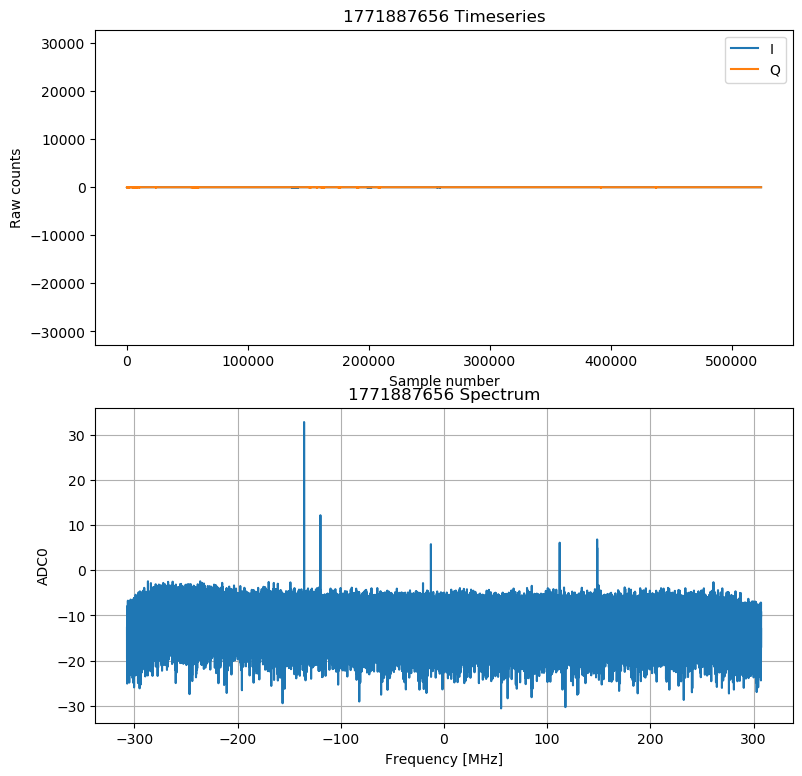

In [23]:
S.read_adc_data(band,make_plot=True,show_plot=True)

Looks like tones are there in second plot. I have a ton of attenuation so first plot looks flat but it likely is real data.

# Debug data

Let's look at the raw DDC IQ data.  Because *reasons* we need some extra functions to decode the I/Q debug data right now.

In [24]:
def first_sublist_index(lst, sub):
    n, m = len(lst), len(sub)
    if m == 0:
        return 0
    for i in range(n - m + 1):
        if lst[i:i+m] == sub:
            return i
    return -1  # not found

def chdec_iq(S,i,q):
    chans = S.which_on(band)
    proc_chans=S.get_processed_channels(band)
    proc_chans = sorted([chan if chan != 22 else 25 for chan in proc_chans])
    chan_debug_indices=[proc_chans.index(chan) for chan in chans]
    
    #decode based on i for now
    nzi_idx=np.nonzero(i)[0]
    lst=list(np.diff(nzi_idx))
    sub=list(np.diff(chan_debug_indices))
    difftrimidx=first_sublist_index(lst, sub)

    dd={}
    chan_offsets=np.diff(chan_debug_indices)
    chan_offsets = np.insert(chan_offsets, 0, 0, axis=0)
    for ichan,chan in enumerate(chans):
        dd[chan]={}
        #print(f'{ichan} {nzi_idx[difftrimidx]+np.sum(chan_offsets[:ichan+1])}')
        dd[chan]['i']=i[nzi_idx[difftrimidx]+np.sum(chan_offsets[:ichan+1])::416]
        dd[chan]['q']=q[nzi_idx[difftrimidx]+np.sum(chan_offsets[:ichan+1])::416]
        #print(chan_offsets[:ichan])

    return dd

Take some I/Q samples and decode.

In [25]:
i,q,sync = S.take_debug_data(band=band,channel=None,rf_iq=True,nsamp=2**24)
dd=chdec_iq(S,i,q)

[ 2026-02-23 23:15:19 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:SysgenCryo:Base[0]:singleChannelReadout 0
[ 2026-02-23 23:15:19 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:SysgenCryo:Base[0]:singleChannelReadoutOpt2 0
[ 2026-02-23 23:15:19 ]  Writing to file : /data/smurf_data/20260223/1771887394/outputs/1771888519.dat
[ 2026-02-23 23:15:19 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:DataBufferSize 16777216
[ 2026-02-23 23:15:19 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:DebugSelect[0] 0
[ 2026-02-23 23:15:19 ]  Data acquisition in progress...
[ 2026-02-23 23:15:19 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:TriggerDaq 1
[ 2026-02-23 23:15:21 ]  Done taking data


Decode data, for historical reasons, is scaled by a small factor that's only relevant for uMUX.  Need to descale.

In [53]:
n_subbands = S.get_number_sub_bands()
digitizer_frequency_mhz = S.get_digitizer_frequency_mhz()
subband_half_width_mhz = (digitizer_frequency_mhz / n_subbands)

descale_factor = 2**23/subband_half_width_mhz
print(f'n_subbands = {n_subbands}\ndigitizer frequency MHz = {digitizer_frequency_mhz}\ndescale_factor = {descale_factor}')

n_subbands = 512
digitizer frequency MHz = 614.4
descale_factor = 6990506.666666667


Text(0, 0.5, 'I [ADC counts?]')

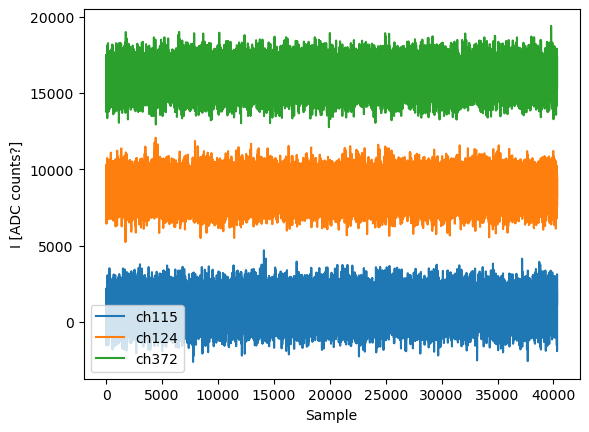

In [32]:
y_plotting_offset = 8000
for idx, ch in enumerate(dd.keys()):
    plt.plot(descale_factor*dd[ch]['i']+y_plotting_offset*idx,label=f'ch{ch}')

plt.legend()
plt.xlabel('Sample')
plt.ylabel('I [ADC counts?]')

Looks good I think? Shawn had trouble with one of his channels returning data with much larger magnitude than the other channels. We're gonna run the following debugging cells anyway.

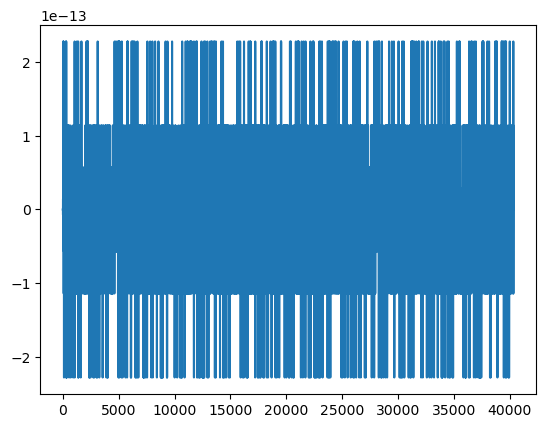

In [33]:
plt.plot(descale_factor*dd[ch]['i'] - np.array(np.round(descale_factor*dd[ch]['i'])))

Not really sure what that means. OK, streaming time.

# Streaming data

What streaming mode, if any, are we in now?

In [35]:
print(f"baySelStream: {S._caget(f'{S.app_core}baySelStream')}")
print(f"modeStream: {S._caget(f'{S.app_core}modeStream')}")

baySelStream: 0
modeStream: 1


Need to select correct baySelStream.

In [94]:
S._caput(f'{S.app_core}baySelStream', int(band/4), write_log=True)
S._caput(f'{S.app_core}modeStream', 1,write_log=True)
print(f"baySelStream: {S._caget(f'{S.app_core}baySelStream',write_log=True)}")
print(f"modeStream: {S._caget(f'{S.app_core}modeStream',write_log=True)}")

[ 2026-02-21 06:16:39 ]  caput smurf_server_s4:AMCc:FpgaTopLevel:AppTop:AppCore:baySelStream 1
[ 2026-02-21 06:16:39 ]  caput smurf_server_s4:AMCc:FpgaTopLevel:AppTop:AppCore:modeStream 1
[ 2026-02-21 06:16:39 ]  caget smurf_server_s4:AMCc:FpgaTopLevel:AppTop:AppCore:baySelStream
[ 2026-02-21 06:16:39 ]  1
baySelStream: 1
[ 2026-02-21 06:16:39 ]  caget smurf_server_s4:AMCc:FpgaTopLevel:AppTop:AppCore:modeStream
[ 2026-02-21 06:16:39 ]  1
modeStream: 1


In [36]:
# Sample rate (can't go above 38ish)
S.flux_ramp_setup(30.0,0)

[ 2026-02-23 23:22:09 ]  Percent full scale = 0.000%


Disable filter and downsample.

In [37]:
# Configure filter / downsample
S.set_filter_disable(True)
S.set_downsample_factor(1)

print(f'S.get_sample_frequency()={S.get_sample_frequency()}')
print(f'S.get_downsample_factor()={S.get_downsample_factor()}')
print(f'S.get_filter_disable()={S.get_filter_disable()}')

S.get_sample_frequency()=30000.0
S.get_downsample_factor()=1
S.get_filter_disable()=1


Ok, so what I'm going to do is try to both stream data the usual way, and also open a raw file using the GUI directly, via the `streamingInterface` System option.

In [38]:
# loss counter tells you if you lost any frames btw rfsoc and pcie card.  
# Very unlikely at these channel counts, but good to check.
loss0 = S.get_frame_loss_cnt()
fname = S.take_stream_data(10,IQ_mode=True) # also dump a short full stream during this - use the `streamingInterface`
loss1 = S.get_frame_loss_cnt()

print(f'Frames lost = {loss1-loss0} should be zero.')

[ 2026-02-23 23:34:05 ]  Starting to take data.
[ 2026-02-23 23:34:05 ]  Input downsample factor is None. Using value already in pyrogue: 1
[ 2026-02-23 23:34:05 ]  CryoCard.do_read failed, retry 1 / 5.
[ 2026-02-23 23:34:05 ]  CryoCard.do_read failed, retry 2 / 5.
[ 2026-02-23 23:34:05 ]  CryoCard.do_read failed, retry 3 / 5.
[ 2026-02-23 23:34:05 ]  CryoCard.do_read failed, retry 4 / 5.
[ 2026-02-23 23:34:05 ]  CryoCard.do_read failed, retry 5 / 5.
[ 2026-02-23 23:34:05 ]  flux_ramp_ac_dc_relay status: Failed to read from cryo card.
[ 2026-02-23 23:34:05 ]  flux_ramp_ac_dc_relay_status = None - NOT A VALID STATE.
[ 2026-02-23 23:34:11 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Unwrapper:reset 1
[ 2026-02-23 23:34:11 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Filter:reset 1
[ 2026-02-23 23:34:11 ]  Writing to file : /data/smurf_data/20260223/1771887394/outputs/1771889652.dat
[ 2026-02-23 23:34:11 ]  /data/smurf_data/20260223/1771887394/outputs/1771889652_mask.txt
[ 2026-02-23 23:3

Did the file get written?

In [39]:
!du -shc /data/smurf_data/20260223/1771887394/outputs/1771889652.dat

44M	/data/smurf_data/20260223/1771887394/outputs/1771889652.dat
44M	total


44 MB, that's a lot of data

Reading the stream data;

In [40]:
t,d,m = S.read_stream_data(fname,IQ_mode=True)

[ 2026-02-23 23:44:51 ]  Reading /data/smurf_data/20260223/1771887394/outputs/1771889652.dat
Processing data records from /data/smurf_data/20260223/1771887394/outputs/1771889652.dat
[ 2026-02-23 23:44:52 ]  2048 elements loaded
[ 2026-02-23 23:44:52 ]  4096 elements loaded
[ 2026-02-23 23:44:52 ]  6144 elements loaded
[ 2026-02-23 23:44:52 ]  8192 elements loaded
[ 2026-02-23 23:44:52 ]  10240 elements loaded
[ 2026-02-23 23:44:53 ]  12288 elements loaded
[ 2026-02-23 23:44:53 ]  14336 elements loaded
[ 2026-02-23 23:44:53 ]  16384 elements loaded
[ 2026-02-23 23:44:53 ]  18432 elements loaded
[ 2026-02-23 23:44:53 ]  20480 elements loaded
[ 2026-02-23 23:44:54 ]  22528 elements loaded
[ 2026-02-23 23:44:54 ]  24576 elements loaded
[ 2026-02-23 23:44:54 ]  26624 elements loaded
[ 2026-02-23 23:44:54 ]  28672 elements loaded
[ 2026-02-23 23:44:54 ]  30720 elements loaded
[ 2026-02-23 23:44:55 ]  32768 elements loaded
[ 2026-02-23 23:44:55 ]  34816 elements loaded
[ 2026-02-23 23:44:55 ]

In [41]:
print(d.shape)

(3, 281860)


Great.  What's it look like?

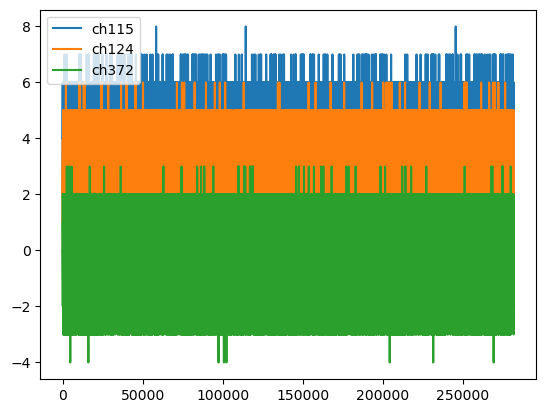

In [55]:
for idx, ch in enumerate(dd.keys()):
    plt.plot(d[idx].real,label=f'ch{ch}')

plt.legend()

Ok.  Good news and bad news.  Good news is it's not totally disimilar from the I/Q data.  What's it look like on shorter sample scales?

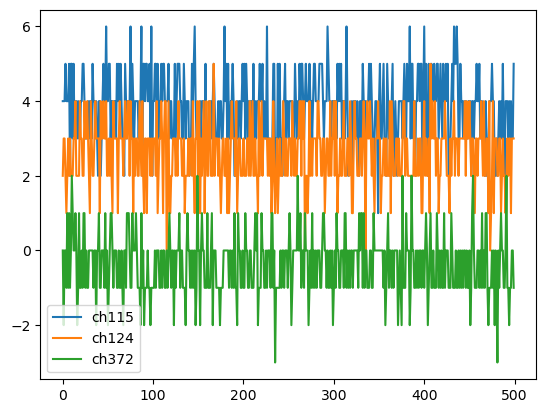

In [58]:
for idx, ch in enumerate(dd.keys()):
    plt.plot(d[idx].real[0:500],label=f'ch{ch}')

plt.legend()

Interesting.  What does just one look like.

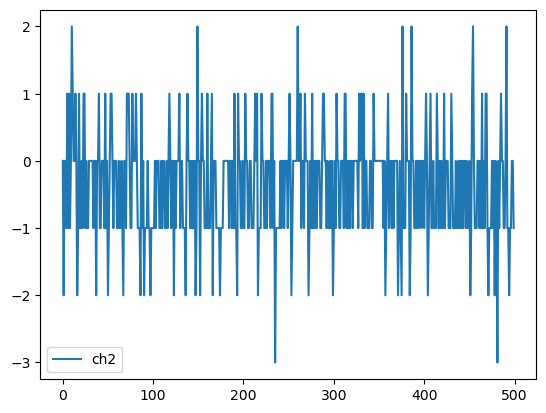

In [47]:
plt.plot(d[2].real[0:500],label=f'ch{ch}')

plt.legend()

Does not look like real data. Does `read_stream_data` apply any scaling?

In [106]:
S.read_stream_data??

Signature:
S.read_stream_data(
    datafile,
    channel=None,
    nsamp=None,
    array_size=None,
    return_header=False,
    return_tes_bias=False,
    write_log=True,
    n_max=2048,
    make_freq_mask=False,
    gcp_mode=False,
    IQ_mode=True,
)
Source:   
    @set_action()
    def read_stream_data(self, datafile, channel=None,
                         nsamp=None, array_size=None,
                         return_header=False,
                         return_tes_bias=False, write_log=True,
                         n_max=2048, make_freq_mask=False,
                         gcp_mode=False, IQ_mode=True):
        """
        Loads data taken with the function stream_data_on.
        Gives back the resonator data in units of phase. Also
        can optionally return the header (which has things
        like the TES bias).

        Args
        ----
        datafile : str
            The full path to the data to read.
        channel : int or int array or None, optional, default None

Looks like no.

Need to find the relation between the streaming data and the debug data.


In [48]:
print(dd[115]['i'][:10]*descale_factor)

[2149. 1378.  905.  -79.  662.  703.  733. 1319. 1948.   22.]


In [49]:
print(dd[115]['q'][:10]*descale_factor)

[ 637. 1114.  380. 1911.  868. 1900. -118. 1576. -127. 1365.]


In [50]:
print(d[0][:10])

[4.+2.j 4.+4.j 4.+2.j 5.+2.j 4.+3.j 4.+2.j 4.+3.j 5.+3.j 2.+2.j 5.+3.j]
